In [2]:
import sys
import time
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
# Матрица смежности
nodes = [
    "Екатерина II",   # 0
    "Петр III",       # 1
    "Павел I",        # 2
    "Александр I",    # 3
    "Николай I",      # 4
    "Александр II",   # 5
    "Александр III",  # 6
    "Николай II"      # 7
]

adj_matrix = [
    [0, 0, 5, 0, 0, 0, 0, 5],
    [4, 0, 34, 0, 0, 0, 4, 0],
    [0, 0, 0, 6, 6, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 7, 0, 0],
    [0, 2, 0, 0, 0, 0, 8, 0],
    [0, 0, 0, 0, 0, 0, 0, 9],
    [0, 2, 0, 0, 0, 0, 0, 0]
]

print("Матрица смежности:")
for i, row in enumerate(adj_matrix):
    print(f"{nodes[i]:15} → {row}")

Матрица смежности:
Екатерина II    → [0, 0, 5, 0, 0, 0, 0, 5]
Петр III        → [4, 0, 34, 0, 0, 0, 4, 0]
Павел I         → [0, 0, 0, 6, 6, 0, 0, 0]
Александр I     → [0, 0, 0, 0, 0, 0, 0, 0]
Николай I       → [0, 0, 0, 0, 0, 7, 0, 0]
Александр II    → [0, 2, 0, 0, 0, 0, 8, 0]
Александр III   → [0, 0, 0, 0, 0, 0, 0, 9]
Николай II      → [0, 2, 0, 0, 0, 0, 0, 0]


In [6]:
# Подпрограмма списка рёбер

def build_edges_from_matrix(matrix, nodes_list):
    """Подпрограмма для построения списка рёбер из матрицы смежности"""
    edges = []
    for i in range(len(nodes_list)):
        for j in range(len(nodes_list)):
            if matrix[i][j] != 0:
                edges.append((nodes_list[i], nodes_list[j], matrix[i][j]))
    return edges

# Вызов подпрограммы
edges_list = build_edges_from_matrix(adj_matrix, nodes)

print("\nРезультат работы подпрограммы: Список рёбер")
for edge in edges_list:
    print(edge)


Результат работы подпрограммы: Список рёбер
('Екатерина II', 'Павел I', 5)
('Екатерина II', 'Николай II', 5)
('Петр III', 'Екатерина II', 4)
('Петр III', 'Павел I', 34)
('Петр III', 'Александр III', 4)
('Павел I', 'Александр I', 6)
('Павел I', 'Николай I', 6)
('Николай I', 'Александр II', 7)
('Александр II', 'Петр III', 2)
('Александр II', 'Александр III', 8)
('Александр III', 'Николай II', 9)
('Николай II', 'Петр III', 2)


In [7]:
# Подпрограмма массива записей

def build_records_from_matrix(matrix, nodes_list):
    """Подпрограмма для представления графа в виде массива записей"""
    records = []
    for i in range(len(nodes_list)):
        parents = []      # Предки (входящие рёбра)
        children = []     # Потомки (исходящие рёбра)
        in_weights = []
        out_weights = []
        
        for j in range(len(nodes_list)):
            # Входящее ребро (j → i)
            if matrix[j][i] != 0:
                parents.append(nodes_list[j])
                in_weights.append(matrix[j][i])
            # Исходящее ребро (i → j)
            if matrix[i][j] != 0:
                children.append(nodes_list[j])
                out_weights.append(matrix[i][j])
        
        record = {
            "Индекс": i,
            "Имя": nodes_list[i],
            "Предки": parents,
            "Потомки": children,
            "Веса входящих": in_weights,
            "Веса исходящих": out_weights
        }
        records.append(record)
    return records

# Вызов подпрограммы
records = build_records_from_matrix(adj_matrix, nodes)

print("\nРезультат работы подпрограммы: Массив записей")
for rec in records:
    print(rec)


Результат работы подпрограммы: Массив записей
{'Индекс': 0, 'Имя': 'Екатерина II', 'Предки': ['Петр III'], 'Потомки': ['Павел I', 'Николай II'], 'Веса входящих': [4], 'Веса исходящих': [5, 5]}
{'Индекс': 1, 'Имя': 'Петр III', 'Предки': ['Александр II', 'Николай II'], 'Потомки': ['Екатерина II', 'Павел I', 'Александр III'], 'Веса входящих': [2, 2], 'Веса исходящих': [4, 34, 4]}
{'Индекс': 2, 'Имя': 'Павел I', 'Предки': ['Екатерина II', 'Петр III'], 'Потомки': ['Александр I', 'Николай I'], 'Веса входящих': [5, 34], 'Веса исходящих': [6, 6]}
{'Индекс': 3, 'Имя': 'Александр I', 'Предки': ['Павел I'], 'Потомки': [], 'Веса входящих': [6], 'Веса исходящих': []}
{'Индекс': 4, 'Имя': 'Николай I', 'Предки': ['Павел I'], 'Потомки': ['Александр II'], 'Веса входящих': [6], 'Веса исходящих': [7]}
{'Индекс': 5, 'Имя': 'Александр II', 'Предки': ['Николай I'], 'Потомки': ['Петр III', 'Александр III'], 'Веса входящих': [7], 'Веса исходящих': [2, 8]}
{'Индекс': 6, 'Имя': 'Александр III', 'Предки': ['Пет

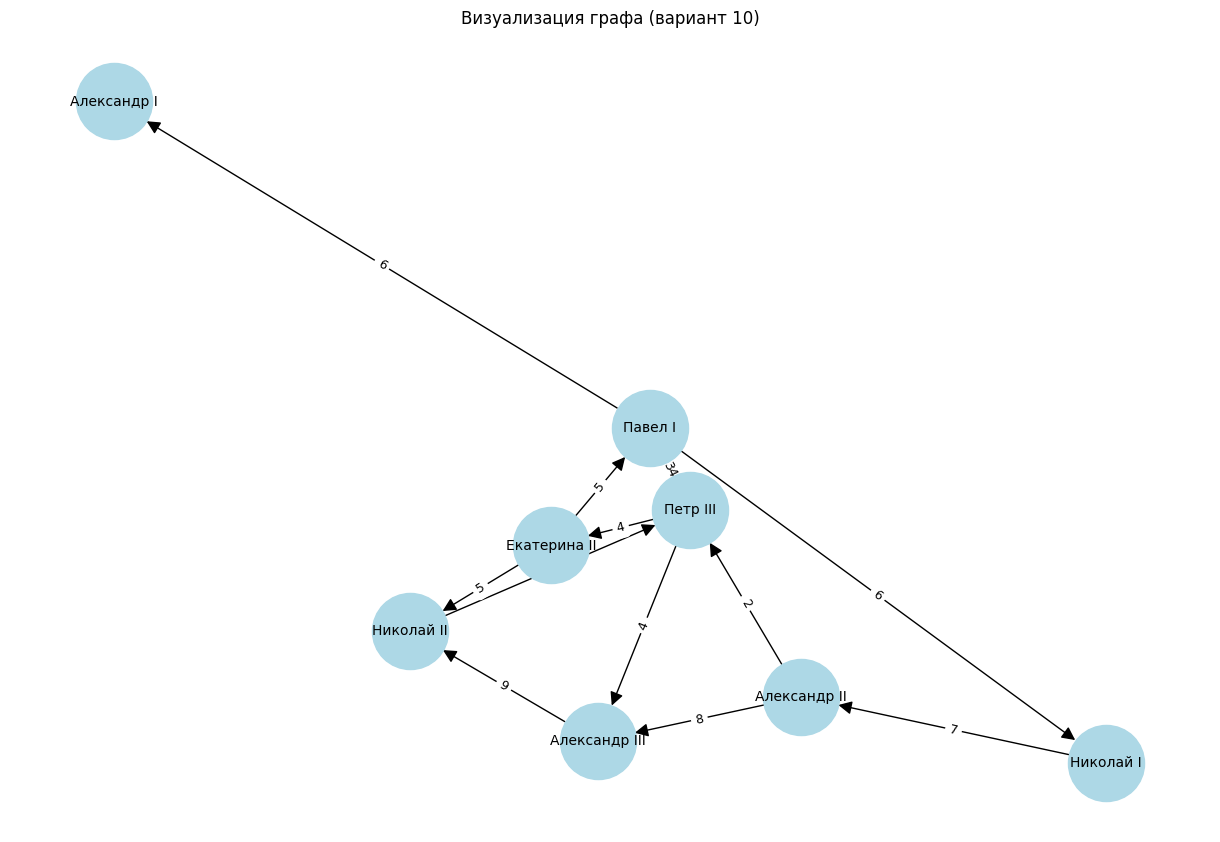

In [8]:
# Визуализация графа
G = nx.DiGraph()
for i, name in enumerate(nodes):
    G.add_node(name)
for i in range(len(nodes)):
    for j in range(len(nodes)):
        if adj_matrix[i][j] != 0:
            G.add_edge(nodes[i], nodes[j], weight=adj_matrix[i][j])

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=3000, font_size=10, arrows=True, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.title("Визуализация графа (вариант 10)")
plt.show()

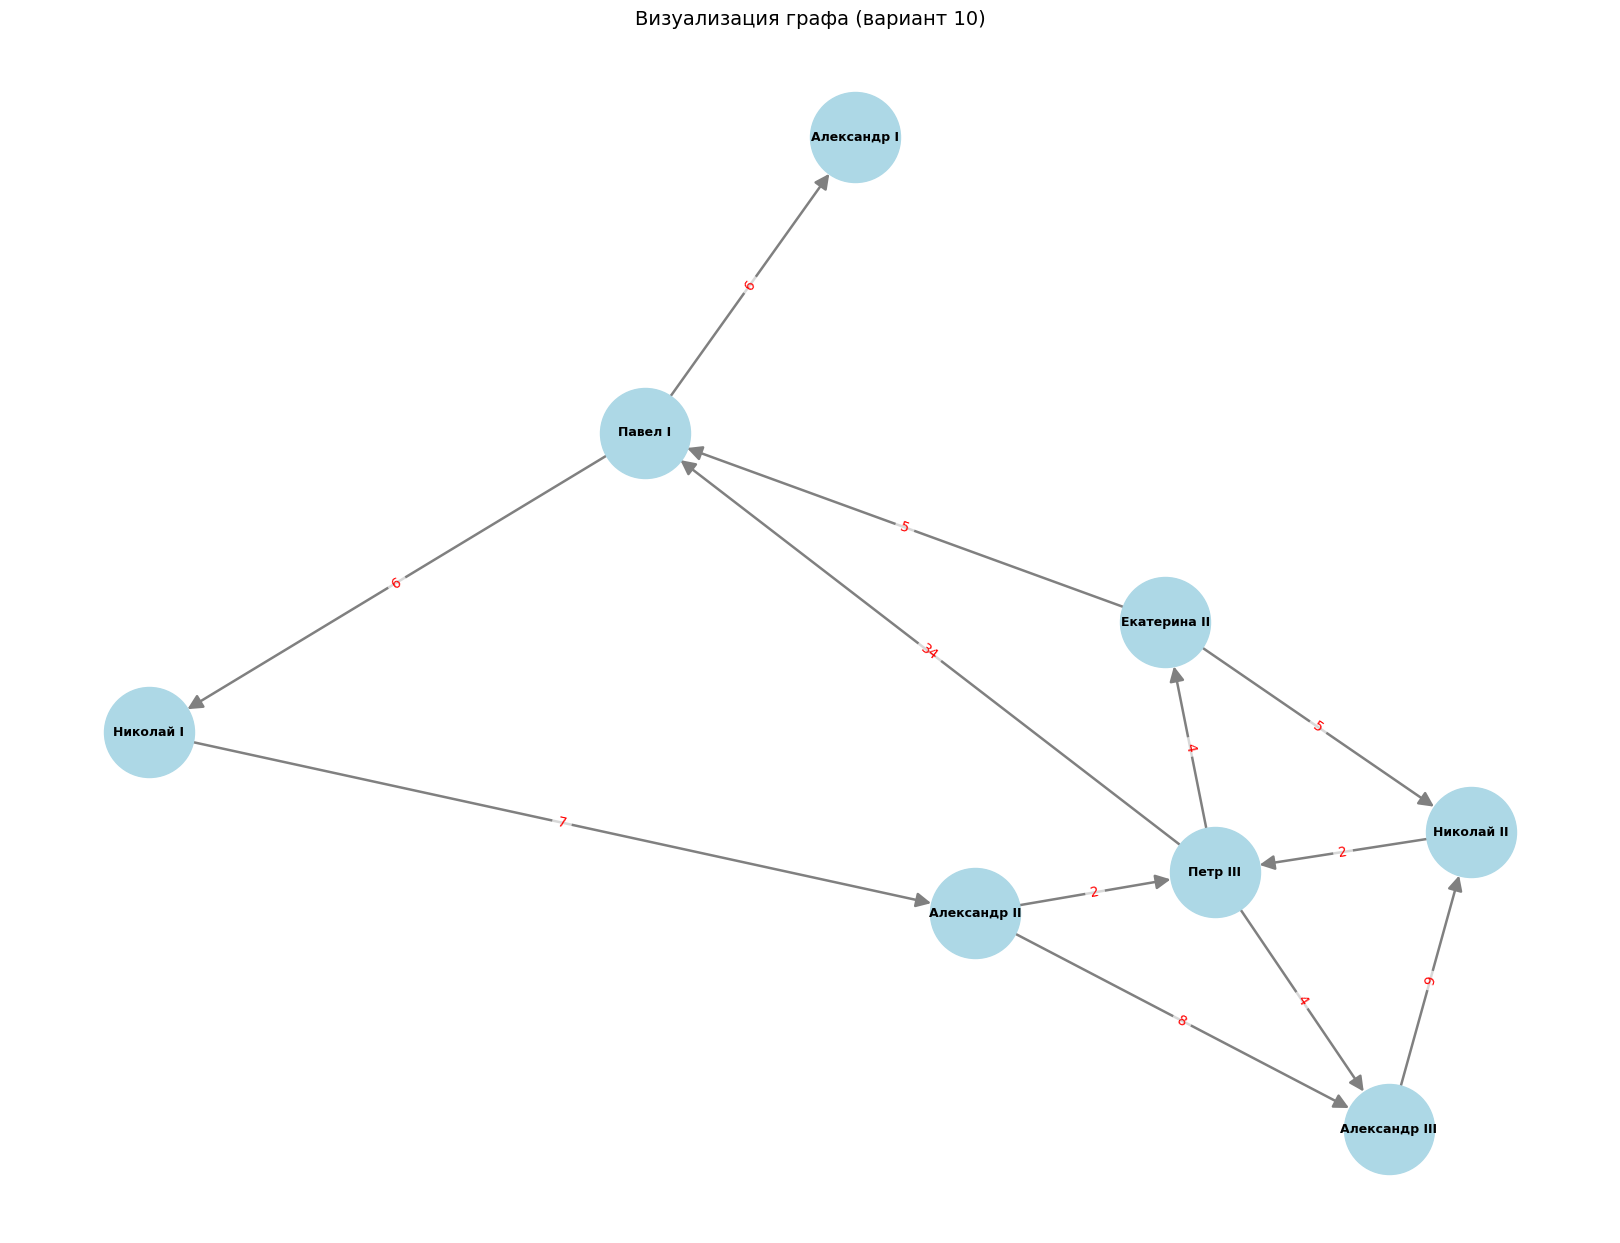

In [12]:
# ==================== ШАГ 5: УЛУЧШЕННАЯ ВИЗУАЛИЗАЦИЯ ГРАФА ====================
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Добавляем вершины
for i, name in enumerate(nodes):
    G.add_node(name)

# Добавляем рёбра с весами
for i in range(len(nodes)):
    for j in range(len(nodes)):
        if adj_matrix[i][j] != 0:
            G.add_edge(nodes[i], nodes[j], weight=adj_matrix[i][j])

# Лучшее расположение для этого графа
pos = nx.kamada_kawai_layout(G)

plt.figure(figsize=(16, 12))          # увеличенный размер холста

nx.draw(G, pos,
        with_labels=False,            # отключаем стандартные метки
        node_color="lightblue",
        node_size=4200,               # увеличенные узлы
        edge_color="gray",
        arrows=True,
        arrowsize=22,
        width=1.8)

# Добавляем метки вершин вручную (чтобы текст помещался)
nx.draw_networkx_labels(G, pos,
                        font_size=9,          # уменьшили шрифт
                        font_weight="bold",
                        font_color="black")
                        
# Добавляем веса рёбер
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=10,
                             font_color="red",
                             bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

plt.title("Визуализация графа (вариант 10)", fontsize=14)
plt.axis("off")
plt.show()

In [13]:
# Группа 1 - Матрица смежности

# 1. Поиск всех соседей заданной вершины
def neighbors_matrix(v_name, nodes_list, matrix):
    """Поиск всех соседей вершины по матрице смежности."""
    idx = nodes_list.index(v_name)
    neighbors = set()
    for j in range(len(nodes_list)):
        if matrix[idx][j] != 0 or matrix[j][idx] != 0:
            neighbors.add(nodes_list[j])
    return sorted(list(neighbors))

# 2. Проверка, образует ли последовательность вершин цепь
def is_chain_matrix(seq, nodes_list, matrix):
    """Проверка, является ли заданная последовательность цепью в графе."""
    for k in range(len(seq) - 1):
        i = nodes_list.index(seq[k])
        j = nodes_list.index(seq[k + 1])
        if matrix[i][j] == 0:
            return False
    return True

# 3. Поиск вершин, у которых сумма весов смежных рёбер > заданной величины
def vertices_sum_matrix(threshold, nodes_list, matrix):
    """Поиск вершин, сумма весов всех смежных рёбер которых превышает порог."""
    result = []
    for i in range(len(nodes_list)):
        total = sum(matrix[i])                     # исходящие
        for row in matrix:
            total += row[i]                        # входящие
        if total > threshold:
            result.append(i)
    return result

# 4. Подсчёт количества рёбер в графе
def count_edges_matrix(matrix):
    """Подсчёт общего количества рёбер в графе."""
    count = 0
    for row in matrix:
        for val in row:
            if val != 0:
                count += 1
    return count


# Тест
print("Результаты 4 подпрограмм для матрицы смежности")

test_vertex = "Петр III"
test_sequence = ["Петр III", "Павел I", "Александр I"]
test_threshold = 30

print("1. Соседи вершины", test_vertex, ":", neighbors_matrix(test_vertex, nodes, adj_matrix))
print("2. Является ли последовательность", test_sequence, "цепью?", 
      "Да" if is_chain_matrix(test_sequence, nodes, adj_matrix) else "Нет")
print("3. Вершины, у которых сумма весов рёбер >", test_threshold, ":", 
      vertices_sum_matrix(test_threshold, nodes, adj_matrix))
print("4. Общее количество рёбер в графе:", count_edges_matrix(adj_matrix))

Результаты 4 подпрограмм для матрицы смежности
1. Соседи вершины Петр III : ['Александр II', 'Александр III', 'Екатерина II', 'Николай II', 'Павел I']
2. Является ли последовательность ['Петр III', 'Павел I', 'Александр I'] цепью? Да
3. Вершины, у которых сумма весов рёбер > 30 : [1, 2]
4. Общее количество рёбер в графе: 12


In [18]:
# Группа 2 - Список рёбер

# 5. Поиск всех соседей заданной вершины
def neighbors_edges(v_name, edges, nodes_list):
    """Поиск всех соседей вершины по списку рёбер."""
    idx = nodes_list.index(v_name)
    neighbors = set()
    for fr_name, to_name, _ in edges:
        if fr_name == v_name:
            neighbors.add(to_name)
        if to_name == v_name:
            neighbors.add(fr_name)
    return sorted(list(neighbors))

# 6. Проверка, образует ли последовательность цепь
def is_chain_edges(seq, edges, nodes_list):
    """Проверка, является ли последовательность цепью по списку рёбер."""
    # Создаём множество пар имён вершин (строка → строка)
    edge_set = {(fr, to) for fr, to, _ in edges}
    for k in range(len(seq) - 1):
        if (seq[k], seq[k + 1]) not in edge_set:
            return False
    return True

# 7. Поиск вершин, сумма весов рёбер > заданной величины
def vertices_sum_edges(threshold, edges, nodes_list):
    """Поиск вершин, у которых сумма весов смежных рёбер > threshold."""
    sums = [0] * len(nodes_list)
    name_to_idx = {name: idx for idx, name in enumerate(nodes_list)}
    for fr_name, to_name, w in edges:
        fr = name_to_idx[fr_name]
        to = name_to_idx[to_name]
        sums[fr] += w
        sums[to] += w
    return [i for i, s in enumerate(sums) if s > threshold]

# 8. Подсчёт количества рёбер в графе
def count_edges_edges(edges):
    """Подсчёт количества рёбер по списку рёбер."""
    return len(edges)


# Тест
print("\nРезультаты 4 подпрограмм для списка рёбер")

test_vertex = "Петр III"
test_sequence = ["Петр III", "Павел I", "Александр I"]
test_threshold = 30

print("5. Соседи вершины", test_vertex, ":", neighbors_edges(test_vertex, edges_list, nodes))
print("6. Является ли последовательность", test_sequence, "цепью?", 
      "Да" if is_chain_edges(test_sequence, edges_list, nodes) else "Нет")
print("7. Вершины, у которых сумма весов рёбер >", test_threshold, ":", 
      vertices_sum_edges(test_threshold, edges_list, nodes))
print("8. Общее количество рёбер в графе:", count_edges_edges(edges_list))


Результаты 4 подпрограмм для списка рёбер
5. Соседи вершины Петр III : ['Александр II', 'Александр III', 'Екатерина II', 'Николай II', 'Павел I']
6. Является ли последовательность ['Петр III', 'Павел I', 'Александр I'] цепью? Да
7. Вершины, у которых сумма весов рёбер > 30 : [1, 2]
8. Общее количество рёбер в графе: 12


In [19]:
# Группа 3 — Массив записей

# 9. Поиск всех соседей заданной вершины
def neighbors_records(v_idx, recs):
    """Поиск всех соседей вершины по массиву записей."""
    for r in recs:
        if r["Индекс"] == v_idx:
            # Убираем дубликаты и сортируем
            return sorted(list(set(r["Предки"] + r["Потомки"])))
    return []


# 10. Проверка, образует ли последовательность цепь
def is_chain_records(seq, recs):
    """Проверка, является ли последовательность цепью по массиву записей."""
    # Быстрый доступ по имени вершины
    rec_map = {r["Имя"]: r for r in recs}
    
    for k in range(len(seq) - 1):
        curr = rec_map[seq[k]]
        # Проверяем наличие направленного ребра
        if seq[k + 1] not in curr["Потомки"]:
            return False
    return True


# 11. Поиск вершин, сумма весов рёбер > заданной величины
def vertices_sum_records(threshold, recs):
    """Поиск вершин, у которых сумма весов смежных рёбер > threshold."""
    result = []
    for r in recs:
        total = sum(r["Веса входящих"]) + sum(r["Веса исходящих"])
        if total > threshold:
            result.append(r["Индекс"])
    return result


# 12. Подсчёт количества рёбер в графе
def count_edges_records(recs):
    """Подсчёт количества рёбер по массиву записей."""
    # Каждое исходящее ребро учитывается один раз
    return sum(len(r["Потомки"]) for r in recs)


# Тест

print("\nРезультаты 4 подпрограмм для массива записей")

test_vertex_idx = 1  # Петр III
test_sequence = ["Петр III", "Павел I", "Александр I"]
test_threshold = 30

print("9. Соседи вершины с индексом", test_vertex_idx, ":",
      neighbors_records(test_vertex_idx, records))

print("10. Является ли последовательность", test_sequence, "цепью?",
      "Да" if is_chain_records(test_sequence, records) else "Нет")

print("11. Вершины, у которых сумма весов рёбер >", test_threshold, ":",
      vertices_sum_records(test_threshold, records))

print("12. Общее количество рёбер в графе:",
      count_edges_records(records))


Результаты 4 подпрограмм для массива записей
9. Соседи вершины с индексом 1 : ['Александр II', 'Александр III', 'Екатерина II', 'Николай II', 'Павел I']
10. Является ли последовательность ['Петр III', 'Павел I', 'Александр I'] цепью? Да
11. Вершины, у которых сумма весов рёбер > 30 : [1, 2]
12. Общее количество рёбер в графе: 12


In [20]:
# Размер в памяти
def deep_getsizeof(obj, seen=None):
    """Рекурсивный подсчёт размера объекта в байтах."""
    size = sys.getsizeof(obj)
    if seen is None:
        seen = set()
    
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    if isinstance(obj, dict):
        size += sum(deep_getsizeof(k, seen) + deep_getsizeof(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set)):
        size += sum(deep_getsizeof(i, seen) for i in obj)

    return size


print("\nРазмеры структур данных (в байтах):")

matrix_size = deep_getsizeof(adj_matrix)
edges_size = deep_getsizeof(edges_list)
records_size = deep_getsizeof(records)

print("Матрица смежности:", matrix_size, "байт")
print("Список рёбер:", edges_size, "байт")
print("Массив записей:", records_size, "байт")

# Замер времени выполнения
REPEATS = 100_000

def measure_time(func, *args):
    """Измерение среднего времени выполнения функции."""
    start = time.perf_counter()
    for _ in range(REPEATS):
        func(*args)
    end = time.perf_counter()
    return (end - start) / REPEATS


print("\nСреднее время выполнения подпрограмм:")

# Тестовые данные
test_vertex_name = "Петр III"
test_vertex_idx = 1
test_sequence = ["Петр III", "Павел I", "Александр I"]
test_threshold = 30

# -------- Матрица --------
print("\nМатрица смежности:")
print("neighbors:", measure_time(neighbors_matrix, test_vertex_name, nodes, adj_matrix))
print("is_chain:", measure_time(is_chain_matrix, test_sequence, nodes, adj_matrix))
print("sum:", measure_time(vertices_sum_matrix, test_threshold, nodes, adj_matrix))
print("count:", measure_time(count_edges_matrix, adj_matrix))

# -------- Список рёбер --------
print("\nСписок рёбер:")
print("neighbors:", measure_time(neighbors_edges, test_vertex_name, edges_list, nodes))
print("is_chain:", measure_time(is_chain_edges, test_sequence, edges_list, nodes))
print("sum:", measure_time(vertices_sum_edges, test_threshold, edges_list, nodes))
print("count:", measure_time(count_edges_edges, edges_list))

# -------- Массив записей --------
print("\nМассив записей:")
print("neighbors:", measure_time(neighbors_records, test_vertex_idx, records))
print("is_chain:", measure_time(is_chain_records, test_sequence, records))
print("sum:", measure_time(vertices_sum_records, test_threshold, records))
print("count:", measure_time(count_edges_records, records))


Размеры структур данных (в байтах):
Матрица смежности: 1328 байт
Список рёбер: 1932 байт
Массив записей: 7354 байт

Среднее время выполнения подпрограмм:

Матрица смежности:
neighbors: 3.075117999997019e-06
is_chain: 1.2062360000072658e-06
sum: 7.621750999996948e-06
count: 3.2786829999986365e-06

Список рёбер:
neighbors: 3.022380000002158e-06
is_chain: 2.3968979999972364e-06
sum: 7.084189999995943e-06
count: 1.3932800000475253e-07

Массив записей:
neighbors: 1.928718999997727e-06
is_chain: 2.5099649999992836e-06
sum: 3.858805999998367e-06
count: 1.7309519999980694e-06
